In [ ]:
import pandas as pd
from db_queries import get_location_metadata
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from tqdm import tqdm
import numpy as np
from matplotlib.ticker import MaxNLocator
from pathlib import Path
import yaml

In [14]:
# Set paths ####################################################################
RAW_DATA_PATH = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/training_data/2026_09_13.01/data.parquet"
GBD_FILE = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/input/gbd_prevalence/gbd_mean_neonatal_mortality_prevalence.parquet"
INFERENCE_FILE_08_03 = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/results/2026_08_03.03/ssp245.parquet"  # Previous most-recent run
INFERENCE_FILE_09_14 = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/results/2026_09_14.01/ssp245.parquet"  # Consumption merged on birth year
INFERENCE_FILE_09_16 = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/results/2026_09_16.02/ssp245.parquet"  # linear fit on log consumption per day
PLOT_OUTPUT = "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/"

In [3]:
df_raw = pd.read_parquet(RAW_DATA_PATH)
df_raw.head()

,year_start,year_end,nid,survey_name,int_year,int_month,sex_id,mothers_age_year,aod_months,age_month,...,q95_prev_9_mo_avg,q99_prev_3_mo_avg,q99_prev_6_mo_avg,q99_prev_9_mo_avg,zone,year_id,age_group_id,int_birth_year_diff_months,log_consumption_pd,sdi
0,2009,2010,13109,DHS_MIS,None,None,2,None,0,0,...,0.666667,0.000000,0.000000,0.000000,23.0,2009,42,0,-0.245692,0.318291
1,2022,2022,538795,None,2022,5,2,18,0,0,...,1.777778,0.000000,0.833333,0.555556,24.0,2021,42,11,1.312609,0.447416
2,2017,2017,353526,None,2017,4,1,20,0,0,...,3.444444,3.666667,1.833333,1.222222,27.0,2017,42,0,2.448691,0.373539
3,2019,2021,467681,DHS,None,None,1,None,0,0,...,0.777778,0.000000,0.000000,0.000000,24.0,2020,42,2,1.619791,0.583046
4,2000,2000,19156,None,2000,2,2,24,0,0,...,0.000000,0.000000,0.000000,0.000000,25.0,1999,42,2,-0.227447,0.340183


In [ ]:
# Add location names
locs = get_location_metadata(location_set_id=39, release_id=16)

df_raw = df_raw.merge(
    locs[["location_id", "location_name", "level", "super_region_name"]],
    on="location_id",
    how="left",
)

Scatters: 
averaged mortality by consumption_pd, 
averaged mortality by log_consumption_pd,
averaged mortality by sdi, 
averaged mortality by log_sdi

Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/mortality_vs_covariates_scatter.pdf


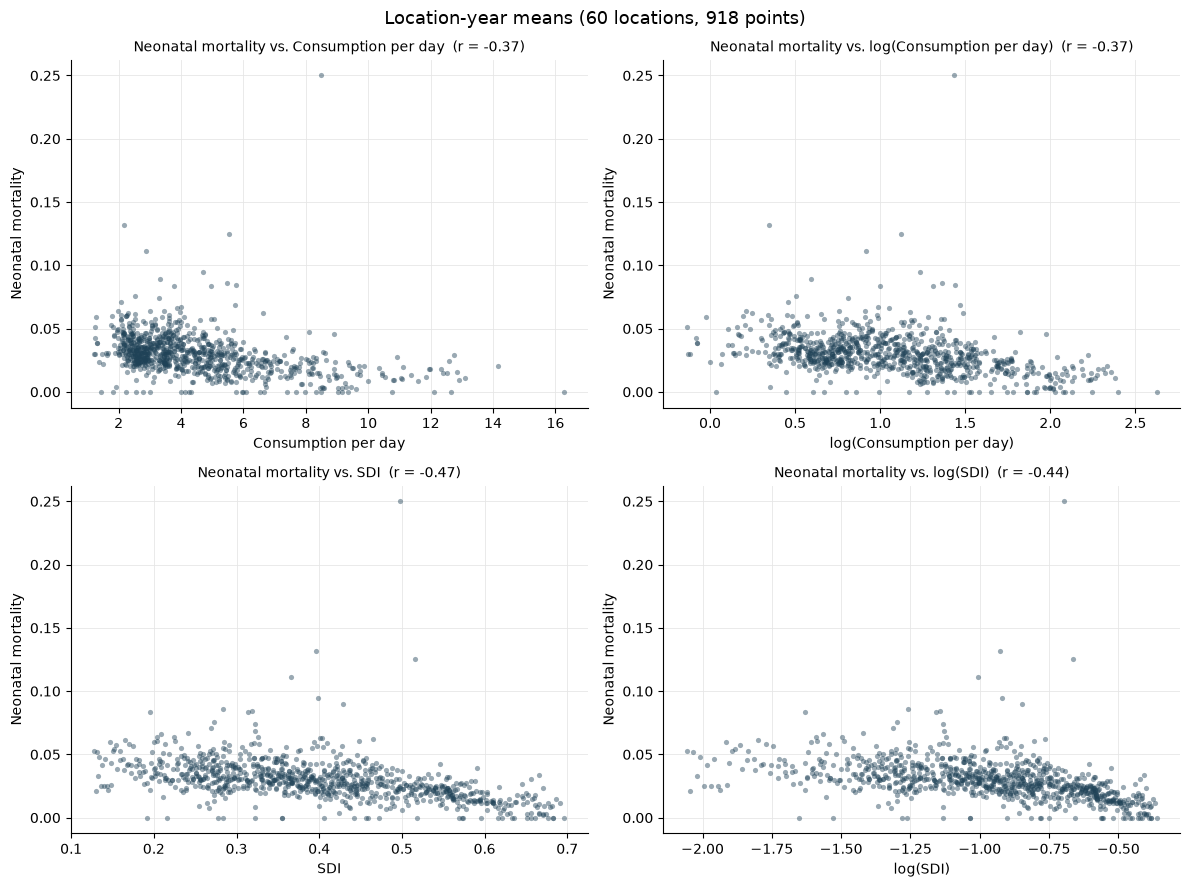

In [6]:
# Location-year means and mortality scatters ###################################
# Average the outcome and each covariate by location_name / birth_year, then
# scatter neonatal mortality against consumption_pd, log_consumption_pd, sdi and
# log_sdi. log_sdi is created here; log_consumption_pd already exists in the data.
MIN_OBS = 0  # set >0 (e.g. 25) to drop sparse location-years

df_raw["log_sdi"] = np.log(df_raw["sdi"])

AGG_VARS = [
    "neonatal_mortality",
    "consumption_pd",
    "log_consumption_pd",
    "sdi",
    "log_sdi",
]

df_agg = (
    df_raw.groupby(["location_name", "birth_year"])
    .agg(**{v: (v, "mean") for v in AGG_VARS}, n_births=("neonatal_mortality", "size"))
    .reset_index()
    .query("n_births >= @MIN_OBS")
)

scatter_specs = [
    ("consumption_pd", "Consumption per day"),
    ("log_consumption_pd", "log(Consumption per day)"),
    ("sdi", "SDI"),
    ("log_sdi", "log(SDI)"),
]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 9))
for ax, (x_col, x_label) in zip(axes.ravel(), scatter_specs):
    ax.scatter(
        df_agg[x_col],
        df_agg["neonatal_mortality"],
        s=14,
        alpha=0.45,
        color="#1f4257",
        linewidths=0,
    )
    r = df_agg[[x_col, "neonatal_mortality"]].corr().iloc[0, 1]
    ax.set_title(f"Neonatal mortality vs. {x_label}  (r = {r:.2f})", fontsize=10)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Neonatal mortality")
    ax.grid(True, color="0.9", linewidth=0.6)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

fig.suptitle(
    f"Location-year means ({df_agg['location_name'].nunique()} locations, "
    f"{len(df_agg)} points)",
    fontsize=13,
)
fig.tight_layout()

plot_path = f"{PLOT_OUTPUT}mortality_vs_covariates_scatter.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

Make scatters for 3 SSA countries only

Make more explanatory version of spline plot on Consumption

Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/covariates_mortality_3countries.pdf


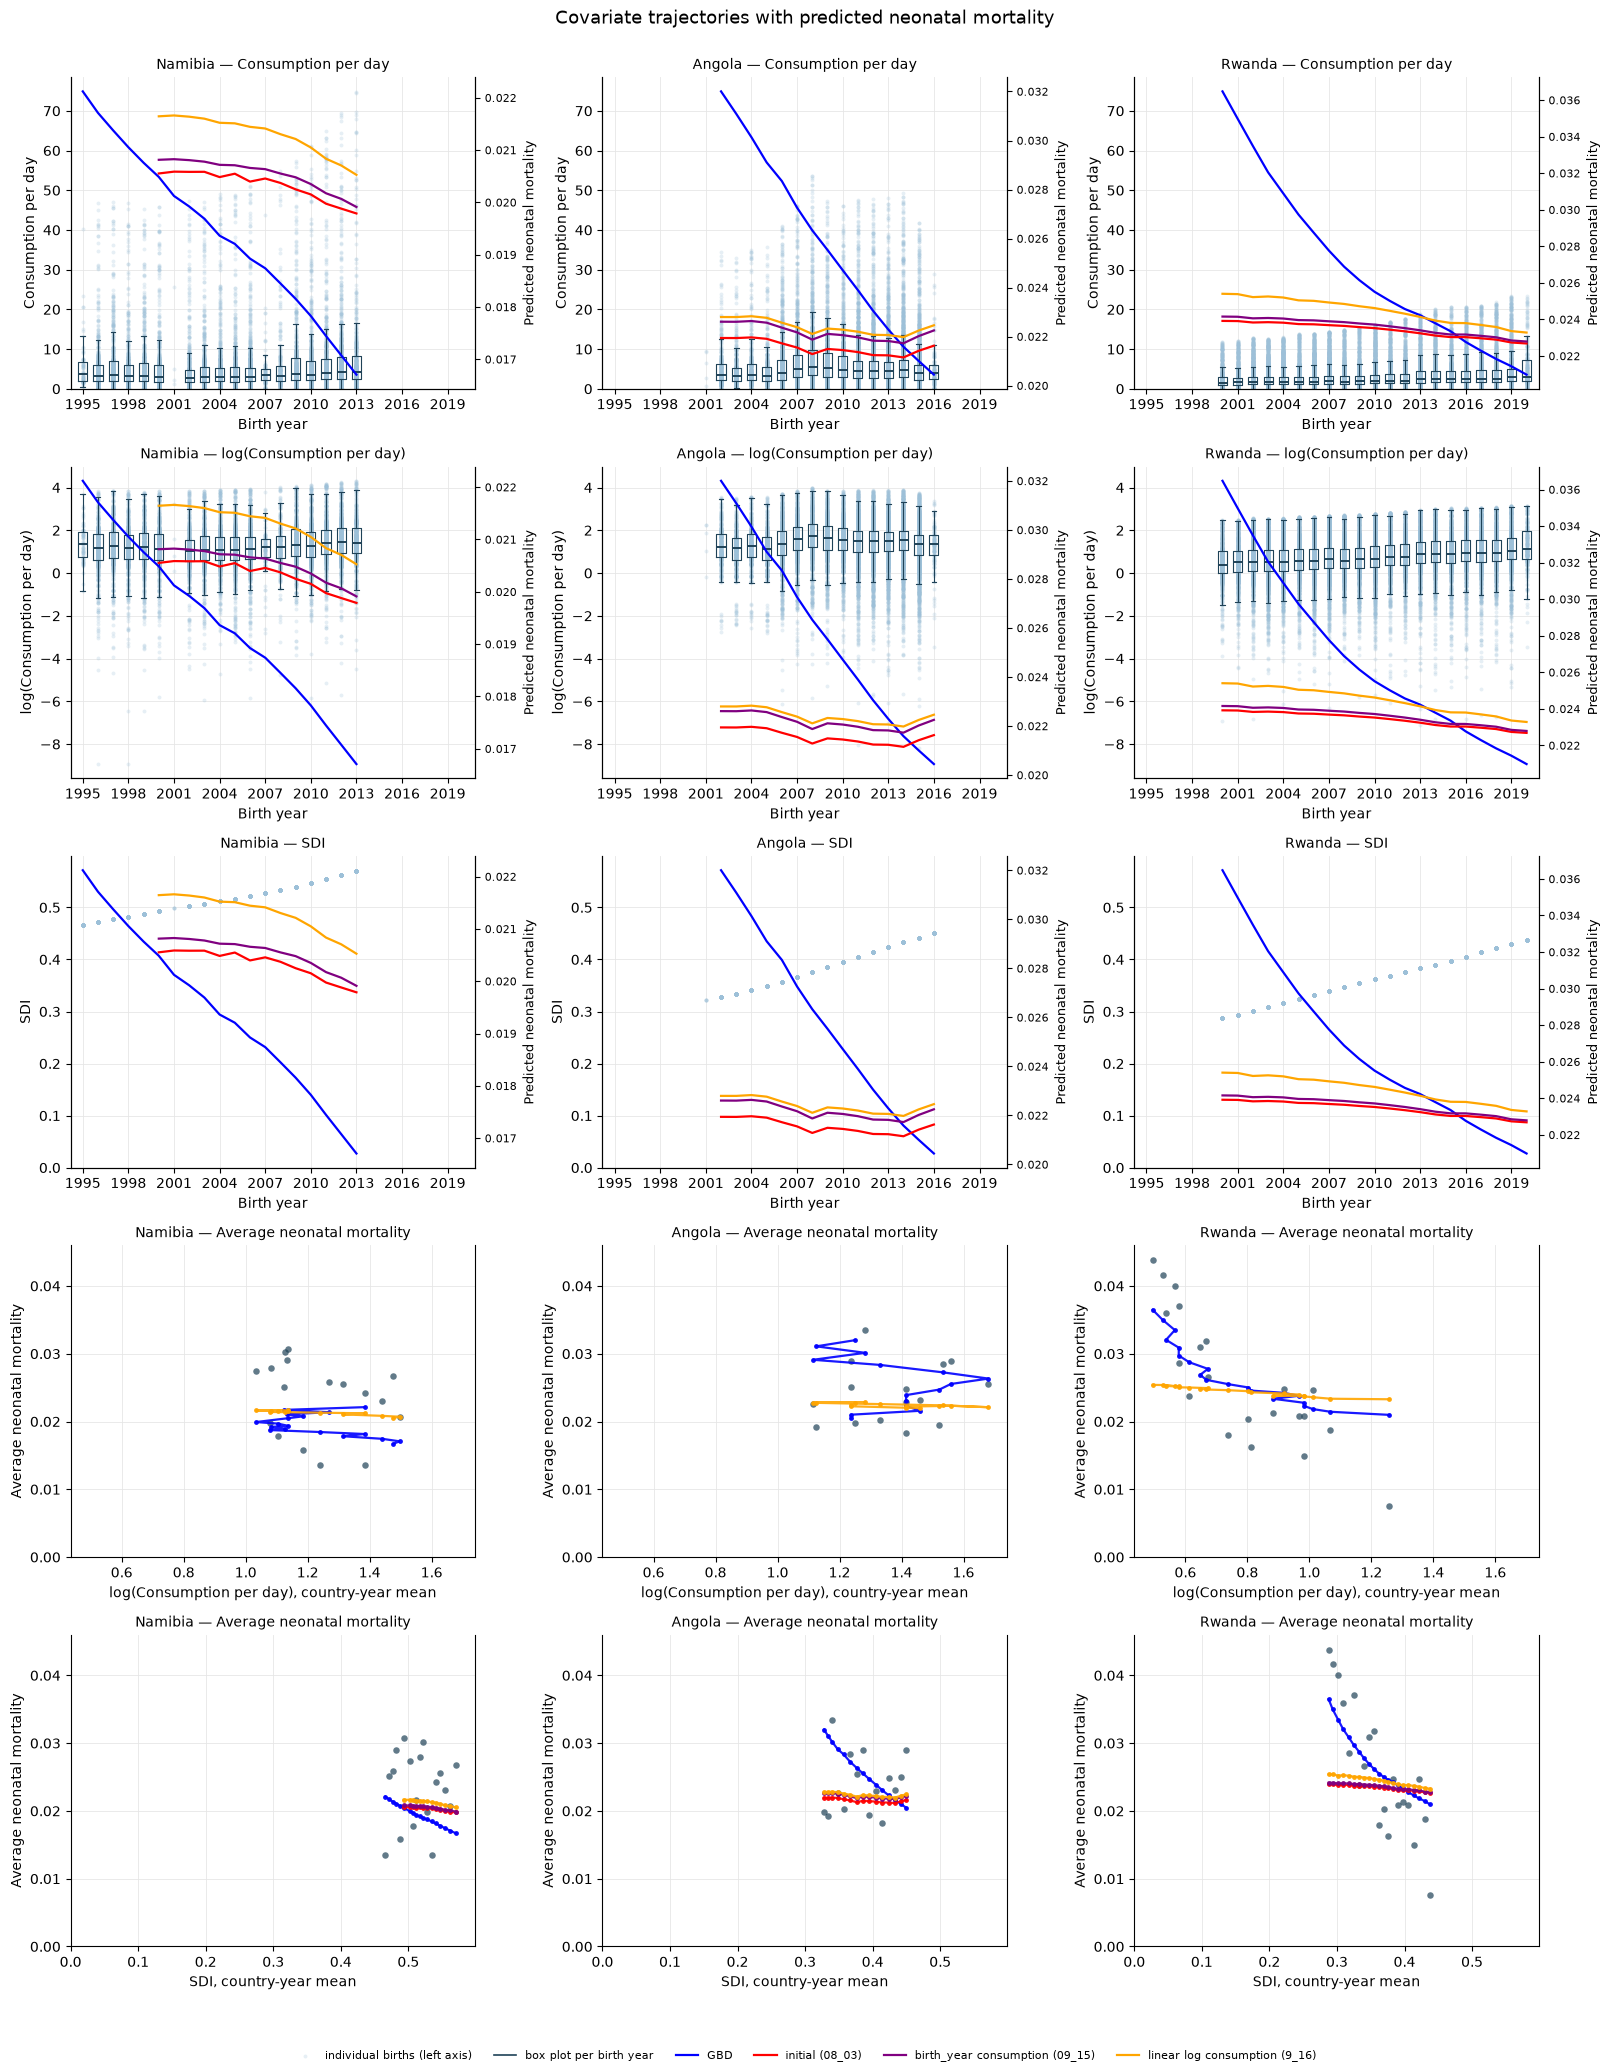

In [25]:
# Covariate trajectories with predicted mortality ##############################
# 3 rows x 3 columns, one column per country. Each row plots consumption_pd,
# log_consumption_pd or sdi against birth_year, with a box plot per birth year on
# the two consumption rows and a twin right axis carrying GBD and the two model
# runs (sex-averaged, clipped to the survey years). Axis limits are shared across
# the three countries and anchored at 0 where the variable is non-negative.
# A final row plots average neonatal mortality against mean log consumption per
# country-year, so it is drawn from country-year means rather than individual
# births and has no boxes, no time axis and no prediction overlay.
# ROW_VARS carries an x column per row; rows whose y column is in AGG_ROWS are
# plotted from df_cy (country-year means) instead of df_raw.
PRED_COLS = {
    "prevalence_gbd": ("blue", "GBD"),
    "prevalence_initial": ("red", "initial (08_03)"),
    "prevalence_birth_year_consumption": ("purple", "birth_year consumption (09_15)"),
    "prevalence_linear_log_consumption": ("orange", "linear log consumption (9_16)"),
}
countries = ["Namibia", "Angola", "Rwanda"]
# (x column, y column, x label, y label)
ROW_VARS = [
    ("birth_year", "consumption_pd", "Birth year", "Consumption per day"),
    ("birth_year", "log_consumption_pd", "Birth year", "log(Consumption per day)"),
    ("birth_year", "sdi", "Birth year", "SDI"),
    (
        "log_consumption_pd",
        "neonatal_mortality",
        "log(Consumption per day), country-year mean",
        "Average neonatal mortality",
    ),
    (
        "sdi",
        "neonatal_mortality",
        "SDI, country-year mean",
        "Average neonatal mortality",
    ),
]
AGG_ROWS = {"neonatal_mortality"}  # rows drawn from country-year means
# Series overlaid on each AGG_ROWS row, keyed by that row's x column; the
# birth_year rows always show all of PRED_COLS.
AGG_PRED_COLS = {
    "log_consumption_pd": ["prevalence_gbd", "prevalence_linear_log_consumption"],
    "sdi": list(PRED_COLS),
}
BOX_ROWS = {"consumption_pd", "log_consumption_pd"}  # rows that also get box plots
ZERO_ANCHOR_ROWS = {
    "consumption_pd",
    "sdi",
    "neonatal_mortality",
}  # log_consumption_pd goes negative
MIN_OBS = 25  # birth-years with fewer births than this get no box
YMAX_QUANTILE = 1.0  # shared left-axis extent; lower it (e.g. 0.99) to tighten
POINT_COLOR = "#9dc0d8"
BOX_COLOR = "#1f4257"


def get_mean_draw(data):
    draw_cols = [c for c in data.columns if c.startswith("draw_")]
    out = data[[c for c in data.columns if "draw_" not in c]].copy()
    out["prevalence"] = data[draw_cols].mean(axis=1)
    return out


# Predictions ##################################################################
key = ["location_id", "year_id", "sex_id"]
gbd = (
    pd.read_parquet(GBD_FILE)
    .reset_index()
    .rename(columns={"gbd_mean_prevalence": "prevalence_gbd"})
)
init = get_mean_draw(pd.read_parquet(INFERENCE_FILE_08_03).reset_index()).rename(
    columns={"prevalence": "prevalence_initial"}
)
lin = get_mean_draw(pd.read_parquet(INFERENCE_FILE_09_14).reset_index()).rename(
    columns={"prevalence": "prevalence_birth_year_consumption"}
)
loglin = get_mean_draw(pd.read_parquet(INFERENCE_FILE_09_16).reset_index()).rename(
    columns={"prevalence": "prevalence_linear_log_consumption"}
)

pred = (
    gbd[key + ["prevalence_gbd"]]
    .merge(init[key + ["prevalence_initial"]], on=key, how="left")
    .merge(lin[key + ["prevalence_birth_year_consumption"]], on=key, how="left")
    .merge(loglin[key + ["prevalence_linear_log_consumption"]], on=key, how="left")
    .merge(locs[["location_id", "location_name"]], on="location_id", how="left")
)
pred = (
    pred[pred["location_name"].isin(countries)]
    .groupby(["location_name", "year_id"], as_index=False)[list(PRED_COLS)]
    .mean()
)

# Country-year means, used by the AGG_ROWS rows ################################
selected = df_raw[df_raw["location_name"].isin(countries)]
df_cy = (
    selected.groupby(["location_name", "birth_year"], as_index=False)
    .agg(
        neonatal_mortality=("neonatal_mortality", "mean"),
        consumption_pd=("consumption_pd", "mean"),
        log_consumption_pd=("log_consumption_pd", "mean"),
        sdi=("sdi", "mean"),
        n_births=("neonatal_mortality", "size"),
    )
    .query("n_births >= @MIN_OBS")
)

# Predictions placed on a covariate x axis, for the AGG_ROWS rows ##############
pred_cy = pred.merge(
    df_cy.rename(columns={"birth_year": "year_id"}).drop(
        columns=["neonatal_mortality", "n_births"]
    ),
    on=["location_name", "year_id"],
    how="inner",
)

# Shared year limits for every birth_year row ##################################
year_counts = selected.groupby(["location_name", "birth_year"]).size()
kept = year_counts[year_counts >= MIN_OBS].index.get_level_values("birth_year")
year_lim = (kept.min() - 0.8, kept.max() + 0.8)


# Axis limits, shared across the three countries ###############################
def _limits(series, anchor_zero):
    hi = float(series.quantile(YMAX_QUANTILE))
    lo = 0.0 if anchor_zero else float(series.quantile(1 - YMAX_QUANTILE))
    pad = 0.05 * (hi - lo)
    return (lo if anchor_zero else lo - pad, hi + pad)


row_lims = []
for x_col, y_col, _, _ in ROW_VARS:
    source = df_cy if y_col in AGG_ROWS else selected
    y_values = source[y_col]
    if y_col in AGG_ROWS:
        # the prediction lines live on this same axis, so include their range
        y_values = pd.concat([y_values, pred_cy[AGG_PRED_COLS[x_col]].stack()])
    ylim = _limits(y_values, y_col in ZERO_ANCHOR_ROWS)
    xlim = (
        None
        if x_col == "birth_year"
        else _limits(source[x_col], x_col in ZERO_ANCHOR_ROWS)
    )
    row_lims.append((xlim, ylim))

# Plot #########################################################################
fig, axes = plt.subplots(
    nrows=len(ROW_VARS),
    ncols=len(countries),
    figsize=(5.4 * len(countries), 4.2 * len(ROW_VARS)),
)
axes = np.atleast_2d(axes)
handles, labels = [], []

for row, (x_col, y_col, x_label, y_label) in enumerate(ROW_VARS):
    for col, country in enumerate(countries):
        ax = axes[row, col]
        aggregated = y_col in AGG_ROWS
        source = df_cy if aggregated else df_raw
        sub = source[source["location_name"] == country]
        ax.scatter(
            sub[x_col],
            sub[y_col],
            s=22 if aggregated else 8,
            alpha=0.7 if aggregated else 0.25,
            color=BOX_COLOR if aggregated else POINT_COLOR,
            linewidths=0,
            zorder=1,
            label="individual births (left axis)",
        )

        counts = sub.groupby("birth_year").size()
        kept_years = counts[counts >= MIN_OBS].index

        if x_col == "birth_year" and y_col in BOX_ROWS and len(kept_years):
            positions = list(kept_years)
            distributions = [
                sub.loc[sub["birth_year"] == yr, y_col].dropna().to_numpy()
                for yr in positions
            ]
            ax.boxplot(
                distributions,
                positions=positions,
                widths=0.6,
                manage_ticks=False,
                showfliers=False,
                zorder=2,
                boxprops={"color": BOX_COLOR, "linewidth": 0.8},
                whiskerprops={"color": BOX_COLOR, "linewidth": 0.8},
                capprops={"color": BOX_COLOR, "linewidth": 0.8},
                medianprops={"color": BOX_COLOR, "linewidth": 1.4},
            )

        if x_col == "birth_year":
            y0, y1 = kept_years.min(), kept_years.max()
            p = pred[
                (pred["location_name"] == country) & pred["year_id"].between(y0, y1)
            ].sort_values("year_id")

            ax2 = ax.twinx()
            for pred_col, (color, label) in PRED_COLS.items():
                ax2.plot(
                    p["year_id"],
                    p[pred_col],
                    color=color,
                    lw=1.6,
                    zorder=3,
                    label=label,
                )
            ax2.set_ylabel("Predicted neonatal mortality", fontsize=9)
            ax2.tick_params(labelsize=8)
            ax2.spines["top"].set_visible(False)
            ax.set_xlim(*year_lim)
            ax.xaxis.set_major_locator(MaxNLocator(integer=True))
            if not handles:
                h1, l1 = ax.get_legend_handles_labels()
                h2, l2 = ax2.get_legend_handles_labels()
                handles, labels = h1 + h2, l1 + l2
                if BOX_ROWS:
                    handles.insert(1, plt.Line2D([], [], color=BOX_COLOR, lw=1.2))
                    labels.insert(1, "box plot per birth year")
        else:
            ax.set_xlim(*row_lims[row][0])
            # y is already mortality here, so the predictions share the left axis
            pm = pred_cy[pred_cy["location_name"] == country].sort_values("year_id")
            for pred_col in AGG_PRED_COLS[x_col]:
                color, label = PRED_COLS[pred_col]
                ax.plot(
                    pm[x_col],
                    pm[pred_col],
                    color=color,
                    lw=1.6,
                    marker="o",
                    ms=2.5,
                    alpha=0.9,
                    zorder=3,
                    label=label,
                )

        ax.set_ylim(*row_lims[row][1])
        ax.set_title(f"{country} — {y_label}", fontsize=10)
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.grid(True, color="0.9", linewidth=0.6)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)

fig.legend(
    handles, labels, loc="lower center", ncol=len(labels), fontsize=8, frameon=False
)
fig.suptitle(
    "Covariate trajectories with predicted neonatal mortality",
    fontsize=13,
)
fig.tight_layout(rect=(0, 0.03, 1, 0.98))

plot_path = f"{PLOT_OUTPUT}covariates_mortality_3countries.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

In [ ]:
# Parametric (non-spline) coefficients for a completed run #####################
# base_model_coefs.parquet holds only the parametric terms; spline terms live in
# the separate *_spline_effects.parquet files and the country random intercept
# lives in base_model_ranef.parquet. The model version is read from the results
# spec rather than assumed, since results and model versions usually differ.
MODEL_ROOT = Path(
    "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition"
    "/neonatal_mortality/models"
)


def print_model_coefficients(inference_file, label=""):
    results_dir = Path(inference_file).parent
    model_version = yaml.safe_load((results_dir / "results_spec.yaml").read_text())[
        "version"
    ]["model"]
    model_dir = MODEL_ROOT / model_version
    spec = yaml.safe_load((model_dir / "specification.yaml").read_text())
    coefs = pd.read_parquet(model_dir / "base_model_coefs.parquet")
    ranef = pd.read_parquet(model_dir / "base_model_ranef.parquet")

    spline_terms = [p["name"] for p in spec["predictors"] if p.get("spline")]
    print(f"{label or results_dir.name}  ->  model {model_version}")
    print(f"  predictors    : {[p['name'] for p in spec['predictors']]}")
    print(f"  spline terms  : {spline_terms or 'none'}  (not in the table below)")
    print(f"  random effect : {len(ranef)} {ranef.index.name} offsets")
    print(coefs.to_string())
    print()
    return coefs

In [ ]:
print_model_coefficients(INFERENCE_FILE_09_16, "linear log consumption (9_16)")

linear log consumption (9_16)  ->  model 2026_09_16.02
  predictors    : ['intercept', 'sex_id', 'birth_year', 'consumption_pd']
  spline terms  : none  (not in the table below)
  random effect : 60 ihme_loc_id offsets
                 Estimate  std_error  statistic        p_value
term                                                          
(Intercept)     34.690024   1.550822  22.368798  7.924268e-111
C(sex_id)2      -0.262168   0.009053 -28.959009  2.161289e-184
birth_year      -0.018961   0.000772 -24.558602  3.500320e-133
consumption_pd  -0.126393   0.005570 -22.691124  5.481930e-114



,Estimate,std_error,statistic,p_value
term,,,,
(Intercept),34.690024,1.550822,22.368798,7.924268e-111
C(sex_id)2,-0.262168,0.009053,-28.959009,2.161289e-184
birth_year,-0.018961,0.000772,-24.558602,3.500320e-133
consumption_pd,-0.126393,0.005570,-22.691124,5.481930e-114


In [ ]:
print_model_coefficients(INFERENCE_FILE_09_14, "consumption merged on birth_year")

consumption merged on birth_year  ->  model 2026_09_14.02
  predictors    : ['intercept', 'sex_id', 'birth_year', 'consumption_pd']
  spline terms  : ['consumption_pd']  (not in the table below)
  random effect : 60 ihme_loc_id offsets
              Estimate  std_error  statistic        p_value
term                                                       
(Intercept)  33.156943   1.558413  21.276097  1.890408e-100
C(sex_id)2   -0.262638   0.009054 -29.007687  5.263294e-185
birth_year   -0.018271   0.000775 -23.580155  6.160273e-123



,Estimate,std_error,statistic,p_value
term,,,,
(Intercept),33.156943,1.558413,21.276097,1.890408e-100
C(sex_id)2,-0.262638,0.009054,-29.007687,5.263294e-185
birth_year,-0.018271,0.000775,-23.580155,6.160273e-123


Make updates of spline plots, based off /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/models/2026_09_14.02/spline_effect_consumption_pd.png

2026_09_14.02: z0 = -3.7513 at birth_year=2020, reference sex, average country (ranef mean 0.000000)
  mortality at partial effect 0 = 2.295%
Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/spline_effect_consumption_pd_with_mortality.pdf


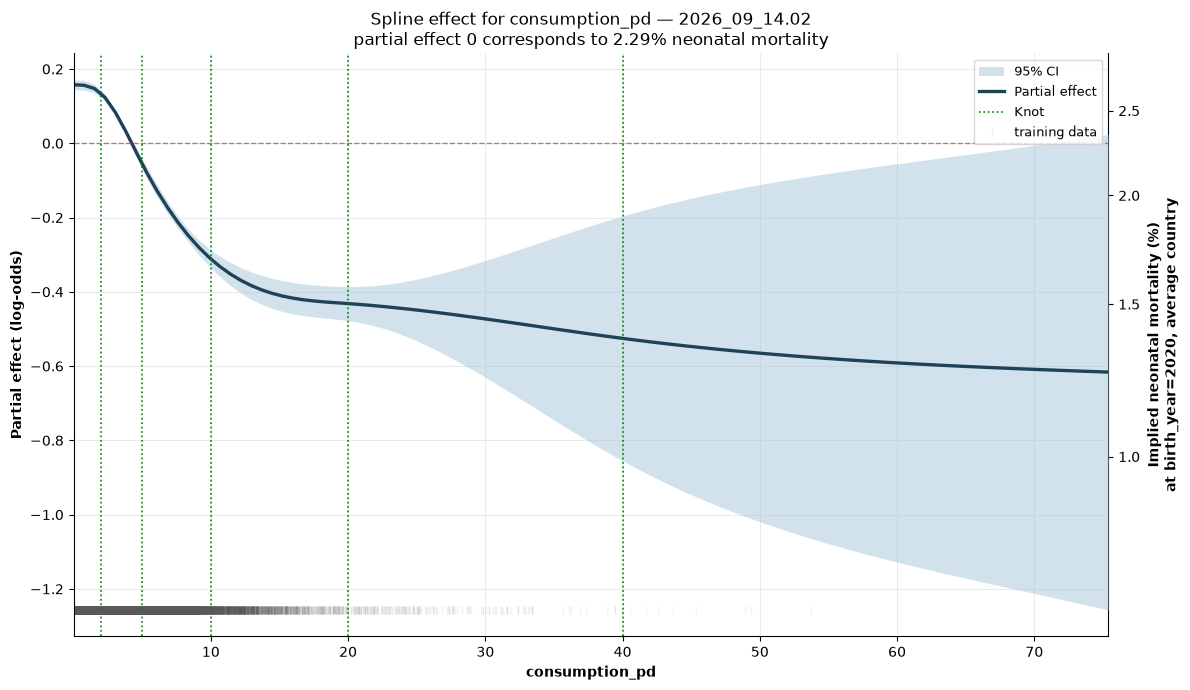

 consumption_pd  partial_effect  implied_nmr_pct  pct_change_vs_$1
            0.5           0.157            2.674             0.321
            1.0           0.153            2.665             0.000
            2.0           0.132            2.611            -2.025
            5.0          -0.055            2.174           -18.437
           10.0          -0.311            1.691           -36.541
           20.0          -0.432            1.502           -43.629
           40.0          -0.525            1.370           -48.600
           75.0          -0.616            1.253           -52.983


In [27]:
# Spline effect with the implied neonatal mortality on a second axis ###########
# Redraws models/<version>/spline_effect_<predictor>.png with a right-hand axis
# giving the neonatal mortality each log-odds value implies.
#
# The partial effect is an offset on the logit scale, so turning it into a
# mortality percentage needs a reference point for everything else in the model.
# We use the model's own linear predictor with the spline contribution set aside:
#   z0 = intercept + birth_year_coef * BASELINE_BIRTH_YEAR
# at the reference sex and an average country (the random intercepts are
# mean-zero, checked below). Implied mortality is then expit(z0 + effect), an
# exact monotone transform of the left axis, so the two axes stay in register.

MODEL_ROOT = Path(
    "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition"
    "/neonatal_mortality/models"
)
SPLINE_MODEL_VERSION = "2026_09_14.02"
SPLINE_PREDICTOR = "consumption_pd"
BASELINE_BIRTH_YEAR = 2020
RUG_SAMPLE = 20000

model_dir = MODEL_ROOT / SPLINE_MODEL_VERSION
spline = pd.read_parquet(model_dir / f"spline_effect_{SPLINE_PREDICTOR}.parquet")
coefs = pd.read_parquet(model_dir / "base_model_coefs.parquet")["Estimate"]
ranef = pd.read_parquet(model_dir / "base_model_ranef.parquet")
spec = yaml.safe_load((model_dir / "specification.yaml").read_text())
knots = [
    k
    for p in spec["predictors"]
    if p["name"] == SPLINE_PREDICTOR and p.get("spline")
    for k in p["spline"]["knots"]
]

z0 = float(coefs["(Intercept)"] + coefs["birth_year"] * BASELINE_BIRTH_YEAR)
baseline_nmr = 1 / (1 + np.exp(-z0))
print(
    f"{SPLINE_MODEL_VERSION}: z0 = {z0:.4f} at birth_year={BASELINE_BIRTH_YEAR}, "
    f"reference sex, average country (ranef mean {ranef.iloc[:, 0].mean():.6f})"
)
print(f"  mortality at partial effect 0 = {100 * baseline_nmr:.3f}%")


def logodds_to_pct(logodds):
    return 100 / (1 + np.exp(-(z0 + np.asarray(logodds, dtype=float))))


def pct_to_logodds(pct):
    p = np.clip(np.asarray(pct, dtype=float) / 100, 1e-12, 1 - 1e-12)
    return np.log(p / (1 - p)) - z0


lo = spline["effect"] - 1.96 * spline["se"]
hi = spline["effect"] + 1.96 * spline["se"]

fig, ax = plt.subplots(figsize=(12, 7))
ax.fill_between(
    spline["value"], lo, hi, color="#9dc0d8", alpha=0.45, linewidth=0, label="95% CI"
)
ax.plot(
    spline["value"], spline["effect"], color="#1f4257", lw=2.4, label="Partial effect"
)
ax.axhline(0, color="#d1495b", lw=1, ls="--", alpha=0.8)
for i, knot in enumerate(knots):
    ax.axvline(knot, color="green", ls=":", lw=1.2, label="Knot" if i == 0 else None)

rug = df_raw.loc[df_raw[SPLINE_PREDICTOR].notna(), SPLINE_PREDICTOR]
rug = rug.sample(min(RUG_SAMPLE, len(rug)), random_state=0)
ax.plot(
    rug,
    np.full(len(rug), lo.min()),
    "|",
    color="0.35",
    ms=6,
    alpha=0.08,
    label="training data",
)

ax.set_xlim(spline["value"].min(), spline["value"].max())
ax.set_xlabel(SPLINE_PREDICTOR, fontweight="bold")
ax.set_ylabel("Partial effect (log-odds)", fontweight="bold")
ax.grid(True, color="0.9", linewidth=0.6)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

pct_axis = ax.secondary_yaxis("right", functions=(logodds_to_pct, pct_to_logodds))
pct_axis.set_ylabel(
    f"Implied neonatal mortality (%)\n"
    f"at birth_year={BASELINE_BIRTH_YEAR}, average country",
    fontweight="bold",
)

ax.legend(loc="upper right", fontsize=9)
ax.set_title(
    f"Spline effect for {SPLINE_PREDICTOR} — {SPLINE_MODEL_VERSION}\n"
    f"partial effect 0 corresponds to {100 * baseline_nmr:.2f}% neonatal mortality",
    fontsize=12,
)
fig.tight_layout()

plot_path = f"{PLOT_OUTPUT}spline_effect_{SPLINE_PREDICTOR}_with_mortality.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

# Reference table over the fitted range
table = pd.DataFrame({"consumption_pd": [0.5, 1, 2, 5, 10, 20, 40, 75]})
table["partial_effect"] = np.interp(
    table["consumption_pd"], spline["value"], spline["effect"]
)
table["implied_nmr_pct"] = logodds_to_pct(table["partial_effect"])
table["pct_change_vs_$1"] = 100 * (
    table["implied_nmr_pct"]
    / logodds_to_pct(np.interp(1, spline["value"], spline["effect"]))
    - 1
)
print(table.round(3).to_string(index=False))

Saved /mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition/neonatal_mortality/plots/spline_effect_consumption_pd_by_country.pdf


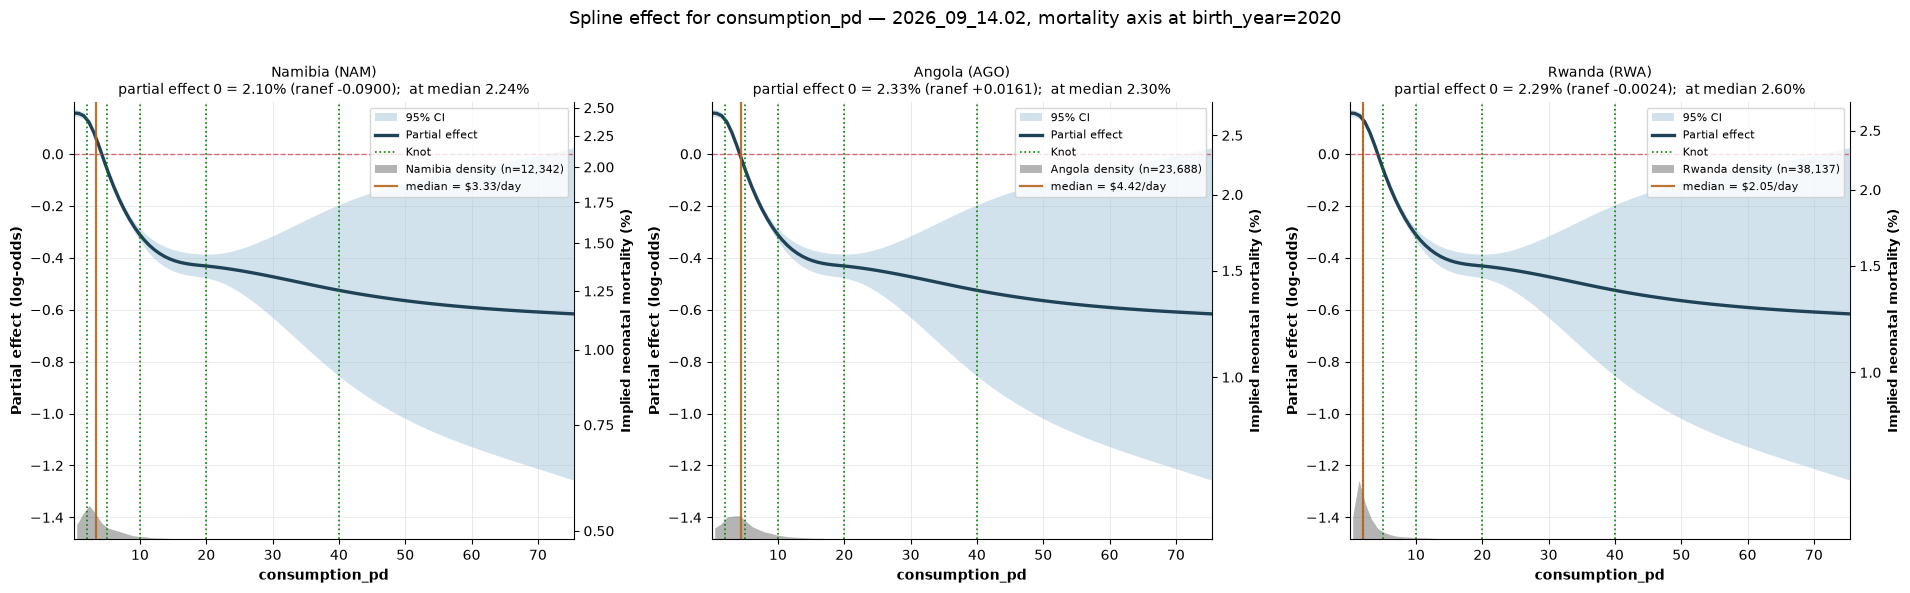

country   p10   p50    p90  nmr_p10_pct  nmr_p50_pct  nmr_p90_pct  p10_to_p90_pct_change
Namibia 1.148 3.333 12.303        2.437        2.236        1.459                -40.131
 Angola 1.397 4.421 12.467        2.695        2.300        1.615                -40.075
 Rwanda 0.811 2.053  6.821        2.665        2.601        1.935                -27.371


In [28]:
# Spline effect per country, with each country's own mortality axis ############
# Same fitted spline in every panel - it is a global fixed effect - but two
# things are country specific:
#   * the density band at the bottom covers only that country's births, on a
#     shared vertical scale, so you can see which part of the curve each country
#     actually occupies and how concentrated it is;
#   * the right-hand mortality axis is anchored with that country's random
#     intercept, so z0 = intercept + birth_year_coef * year + ranef[country].

SPLINE_MODEL_ROOT = Path(
    "/mnt/team/rapidresponse/pub/population/modeling/climate_malnutrition"
    "/neonatal_mortality/models"
)
SPLINE_MODEL = "2026_09_14.02"
SPLINE_VAR = "consumption_pd"
SPLINE_BASELINE_YEAR = 2020
SPLINE_COUNTRIES = ["Namibia", "Angola", "Rwanda"]
DENSITY_BINS = 80
DENSITY_FRAC = 0.16  # share of the panel height given to the density band

_dir = SPLINE_MODEL_ROOT / SPLINE_MODEL
_spline = pd.read_parquet(_dir / f"spline_effect_{SPLINE_VAR}.parquet")
_coefs = pd.read_parquet(_dir / "base_model_coefs.parquet")["Estimate"]
_ranef = pd.read_parquet(_dir / "base_model_ranef.parquet")
_spec = yaml.safe_load((_dir / "specification.yaml").read_text())
_knots = [
    k
    for p in _spec["predictors"]
    if p["name"] == SPLINE_VAR and p.get("spline")
    for k in p["spline"]["knots"]
]
_iso = locs.set_index("location_name")["ihme_loc_id"]

_lo = _spline["effect"] - 1.96 * _spline["se"]
_hi = _spline["effect"] + 1.96 * _spline["se"]

# One shared vertical scale for the density bands, so the panels are comparable
_edges = np.linspace(_spline["value"].min(), _spline["value"].max(), DENSITY_BINS + 1)
_centres = 0.5 * (_edges[:-1] + _edges[1:])
_densities = {
    country: np.histogram(
        df_raw.loc[df_raw["location_name"] == country, SPLINE_VAR].dropna(),
        bins=_edges,
        density=True,
    )[0]
    for country in SPLINE_COUNTRIES
}
_density_max = max(d.max() for d in _densities.values())

# Panel limits: the CI band, plus room underneath for the density
_span = _hi.max() - _lo.min()
_y_bottom = _lo.min() - DENSITY_FRAC * _span
_y_top = _hi.max() + 0.02 * _span

fig, axes = plt.subplots(
    nrows=1, ncols=len(SPLINE_COUNTRIES), figsize=(6.4 * len(SPLINE_COUNTRIES), 6)
)
axes = np.atleast_1d(axes)

for ax, country in zip(axes, SPLINE_COUNTRIES):
    iso = _iso.loc[country]
    z0 = float(
        _coefs["(Intercept)"]
        + _coefs["birth_year"] * SPLINE_BASELINE_YEAR
        + _ranef.loc[iso, "offset"]
    )

    def to_pct(logodds, z0=z0):
        return 100 / (1 + np.exp(-(z0 + np.asarray(logodds, dtype=float))))

    def to_logodds(pct, z0=z0):
        p = np.clip(np.asarray(pct, dtype=float) / 100, 1e-12, 1 - 1e-12)
        return np.log(p / (1 - p)) - z0

    ax.fill_between(
        _spline["value"],
        _lo,
        _hi,
        color="#9dc0d8",
        alpha=0.45,
        linewidth=0,
        label="95% CI",
    )
    ax.plot(
        _spline["value"],
        _spline["effect"],
        color="#1f4257",
        lw=2.4,
        label="Partial effect",
    )
    ax.axhline(0, color="#d1495b", lw=1, ls="--", alpha=0.8)
    for i, knot in enumerate(_knots):
        ax.axvline(
            knot, color="green", ls=":", lw=1.2, label="Knot" if i == 0 else None
        )

    country_values = df_raw.loc[
        (df_raw["location_name"] == country) & df_raw[SPLINE_VAR].notna(), SPLINE_VAR
    ]
    band = _densities[country] / _density_max * DENSITY_FRAC * _span
    ax.fill_between(
        _centres,
        _y_bottom,
        _y_bottom + band,
        color="0.35",
        alpha=0.45,
        linewidth=0,
        label=f"{country} density (n={len(country_values):,})",
    )
    median = float(country_values.median())
    ax.axvline(
        median, color="#b5651d", lw=1.6, alpha=0.9, label=f"median = ${median:.2f}/day"
    )

    ax.set_xlim(_spline["value"].min(), _spline["value"].max())
    ax.set_ylim(_y_bottom, _y_top)
    ax.set_xlabel(SPLINE_VAR, fontweight="bold")
    ax.set_ylabel("Partial effect (log-odds)", fontweight="bold")
    ax.grid(True, color="0.9", linewidth=0.6)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

    pct_axis = ax.secondary_yaxis("right", functions=(to_pct, to_logodds))
    pct_axis.set_ylabel("Implied neonatal mortality (%)", fontweight="bold", fontsize=9)

    ax.set_title(
        f"{country} ({iso})\n"
        f"partial effect 0 = {to_pct(0.0):.2f}% "
        f"(ranef {_ranef.loc[iso, 'offset']:+.4f});  "
        f"at median {to_pct(np.interp(median, _spline['value'], _spline['effect'])):.2f}%",
        fontsize=10,
    )
    ax.legend(loc="upper right", fontsize=8)

fig.suptitle(
    f"Spline effect for {SPLINE_VAR} — {SPLINE_MODEL}, "
    f"mortality axis at birth_year={SPLINE_BASELINE_YEAR}",
    fontsize=13,
)
fig.tight_layout(rect=(0, 0, 1, 0.97))

plot_path = f"{PLOT_OUTPUT}spline_effect_{SPLINE_VAR}_by_country.pdf"
fig.savefig(plot_path, bbox_inches="tight")
print(f"Saved {plot_path}")
plt.show()

# Where each country actually sits on the curve
rows = []
for country in SPLINE_COUNTRIES:
    iso = _iso.loc[country]
    z0 = float(
        _coefs["(Intercept)"]
        + _coefs["birth_year"] * SPLINE_BASELINE_YEAR
        + _ranef.loc[iso, "offset"]
    )
    v = df_raw.loc[df_raw["location_name"] == country, SPLINE_VAR]
    q = v.quantile([0.1, 0.5, 0.9])
    eff = np.interp(q, _spline["value"], _spline["effect"])
    nmr = 100 / (1 + np.exp(-(z0 + eff)))
    rows.append(
        {
            "country": country,
            "p10": q.iloc[0],
            "p50": q.iloc[1],
            "p90": q.iloc[2],
            "nmr_p10_pct": nmr[0],
            "nmr_p50_pct": nmr[1],
            "nmr_p90_pct": nmr[2],
            "p10_to_p90_pct_change": 100 * (nmr[2] / nmr[0] - 1),
        }
    )
print(pd.DataFrame(rows).round(3).to_string(index=False))